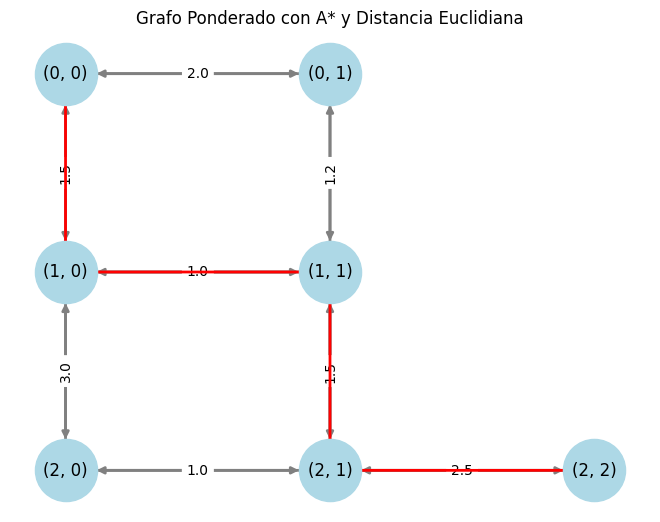

In [1]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def calcular_distancia_euclidiana(punto_a, punto_b):
    # Calcula la distancia en linea recta entre dos puntos (x, y)
    return ((punto_a[0] - punto_b[0]) ** 2 + (punto_a[1] - punto_b[1]) ** 2) ** 0.5

def a_star(grafo, inicio, objetivo):
    # La cola de prioridad almacena los nodos pendientes por explorar ordenados por costo
    cola_prioridad = []
    heapq.heappush(cola_prioridad, (0, inicio))

    # Almacena el nodo previo de cada posicion para poder reconstruir el camino
    procedencia = {}

    # Almacena el costo real (g) desde el inicio hasta cada nodo
    costo_g = {nodo: float('inf') for nodo in grafo}
    costo_g[inicio] = 0

    # Almacena el costo total estimado (f = g + h) para cada nodo
    costo_f = {nodo: float('inf') for nodo in grafo}
    costo_f[inicio] = calcular_distancia_euclidiana(inicio, objetivo)

    while cola_prioridad:
        _, actual = heapq.heappop(cola_prioridad)

        # Si llegamos al objetivo, reconstruimos y retornamos el camino
        if actual == objetivo:
            return reconstruir_camino(procedencia, actual)

        # Exploramos los vecinos y el peso de las aristas del nodo actual
        for vecino, costo in grafo[actual].items():
            tentativo_g = costo_g[actual] + costo

            # Si encontramos un camino mejor hacia el vecino, actualizamos sus costos y procedencia
            if tentativo_g < costo_g[vecino]:
                procedencia[vecino] = actual
                costo_g[vecino] = tentativo_g
                costo_f[vecino] = costo_g[vecino] + calcular_distancia_euclidiana(vecino, objetivo)
                heapq.heappush(cola_prioridad, (costo_f[vecino], vecino))

    # Retorna None si no se encuentra un camino posible
    return None

def reconstruir_camino(procedencia, actual):
    # Reconstruye el camino paso a paso desde el objetivo hasta el inicio
    camino_total = [actual]
    while actual in procedencia:
        actual = procedencia[actual]
        camino_total.append(actual)
    camino_total.reverse()
    return camino_total

def convertir_camino_a_aristas(camino):
    # Convierte la lista de nodos del camino en una lista de pares de aristas
    return [(camino[i], camino[i + 1]) for i in range(len(camino) - 1)]

# Grafo ponderado representado como un diccionario de diccionarios con pesos en las aristas
grafo = {
    (0, 0): {(1, 0): 1.5, (0, 1): 2.0},
    (1, 0): {(0, 0): 1.5, (1, 1): 1.0, (2, 0): 3.0},
    (0, 1): {(0, 0): 2.0, (1, 1): 1.2},
    (1, 1): {(1, 0): 1.0, (0, 1): 1.2, (2, 1): 1.5},
    (2, 0): {(1, 0): 3.0, (2, 1): 1.0},
    (2, 1): {(2, 0): 1.0, (1, 1): 1.5, (2, 2): 2.5},
    (2, 2): {(2, 1): 2.5}
}

# Definimos el nodo de inicio y el nodo objetivo
inicio = (0, 0)
objetivo = (2, 2)

# Creamos el grafo dirigido con NetworkX y agregamos las aristas con sus pesos
G = nx.DiGraph()
for nodo, vecinos in grafo.items():
    for destino, peso in vecinos.items():
        G.add_edge(nodo, destino, weight=peso)

# Ejecutamos el algoritmo A* para obtener el camino optimo
camino = a_star(grafo, inicio, objetivo)

# Configuramos las posiciones, dibujamos el grafo completo, las etiquetas de pesos y resaltamos el camino en rojo
posiciones = {nodo: (nodo[1], -nodo[0]) for nodo in grafo}
nx.draw(G, posiciones, with_labels=True, node_color='lightblue', node_size=2000, edge_color='gray', width=2)
etiquetas_pesos = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, posiciones, edge_labels=etiquetas_pesos)
nx.draw_networkx_edges(G, posiciones, edgelist=convertir_camino_a_aristas(camino), edge_color='red', width=2)
plt.title('Grafo Ponderado con A* y Distancia Euclidiana')
plt.show()